# Lab 6- IT443: Testing Unimodality using KDE and Bootstrap
## Virat Shrimali - 202303061

## Problem Statement

We aim to test the hypothesis:

$$
H_0: \text{The underlying distribution is unimodal}
$$

against the alternative that the distribution is not unimodal.

We use:
- Kernel Density Estimation (KDE)
- Critical Bandwidth
- Bootstrap-based hypothesis testing

We consider two datasets:
- Dataset A: $$\mathcal{N}(0,1)$$ (unimodal)
- Dataset B: $$0.5\mathcal{N}(-2,1) + 0.5\mathcal{N}(2,1)$$ (bimodal)

## Methodology

### 1. Kernel Density Estimation

The KDE estimator is:

$$
\hat{f}_h(x) = \frac{1}{nh} \sum_{i=1}^{n} \phi\left(\frac{x - X_i}{h}\right)
$$

- $h$ is the bandwidth (controls smoothness)
- Small $h$ → noisy estimate
- Large $h$ → smoother estimate

---

### 2. Critical Bandwidth

Define:

$$
\hat{h} = \min \{ h : \hat{f}_h(x) \text{ is unimodal} \}
$$

We:
- Increase $h$ gradually
- Find smallest $h$ such that KDE has only one mode

---

### 3. Bootstrap Test

- Generate $$B = 500$$ bootstrap samples
- Compute $$\hat{h}^*(b)$$ for each

Achieved Significance Level (ASL):

$$
ASL = \frac{\#\{\hat{h}^*(b) \geq \hat{h}\}}{B}
$$

---

### 4. Decision Rule

Reject $$H_0$$ if:

$$
ASL < \alpha = 0.05
$$

## Imports

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.signal import find_peaks

np.random.seed(42)

## Data Simulation

We generate:
- Dataset A: $$\mathcal{N}(0,1)$$
- Dataset B: mixture of two Gaussians

In [7]:
np.random.seed(0)
n = 200

# Dataset A
X_A = np.random.normal(0, 1, n)

# Dataset B (mixture)
X_B = np.concatenate([
    np.random.normal(-2, 1, n//2),
    np.random.normal(2, 1, n//2)
])

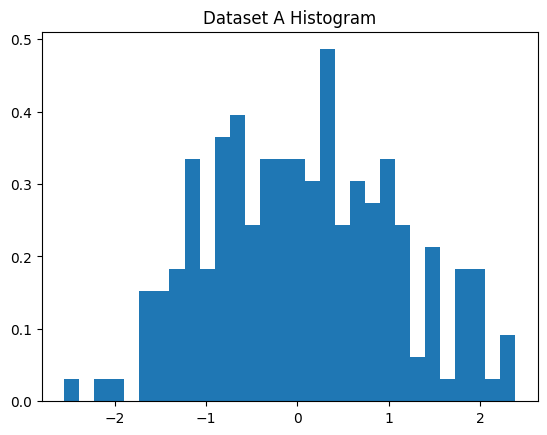

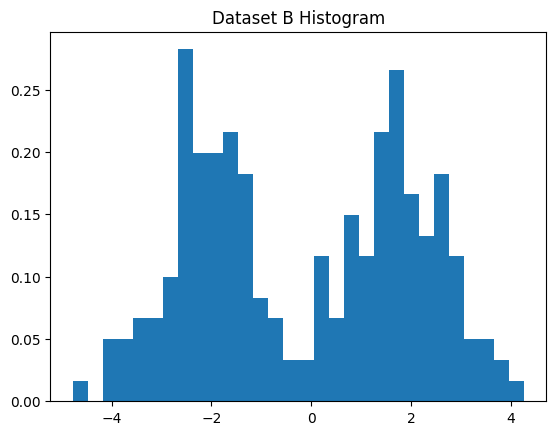

In [8]:
# Visualization of the raw distribution
plt.hist(X_A, bins=30, density=True)
plt.title("Dataset A Histogram")
plt.show()

plt.hist(X_B, bins=30, density=True)
plt.title("Dataset B Histogram")
plt.show()

## Kernel Density Estimation

We implement Gaussian KDE manually.

In [9]:
def kde(x, data, h):
    n = len(data)
    return np.sum(norm.pdf((x[:, None] - data)/h), axis=1) / (n * h)

## KDE Plots

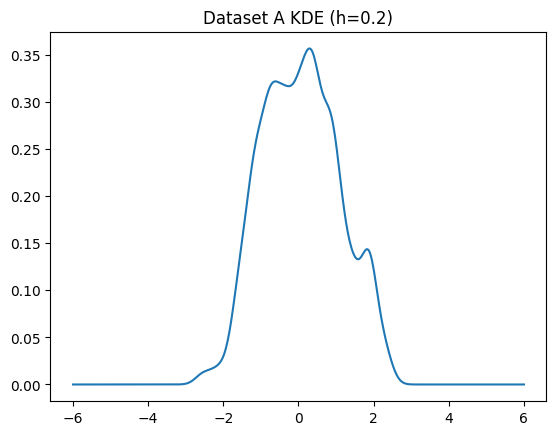

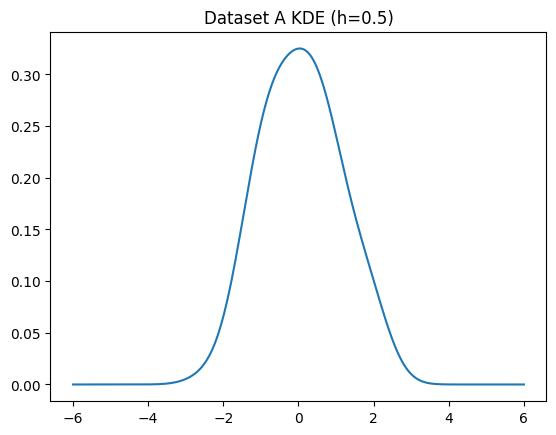

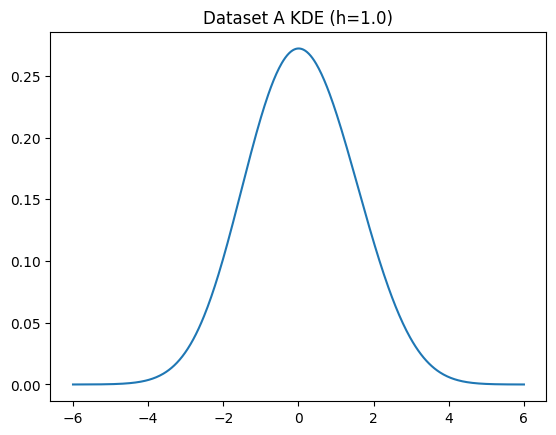

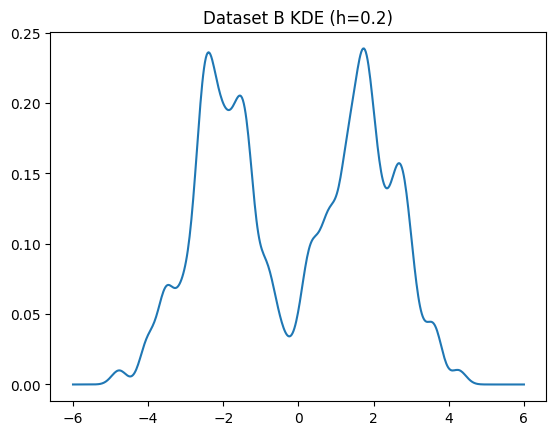

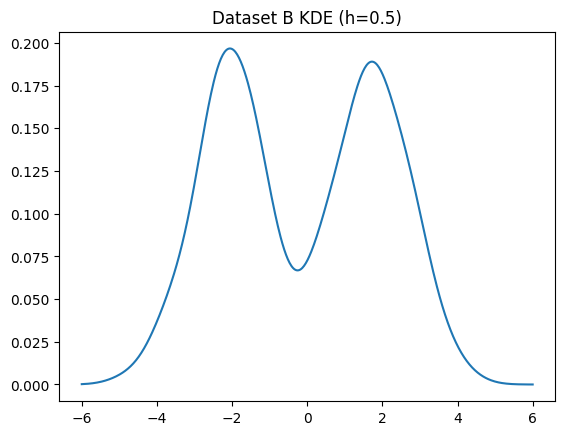

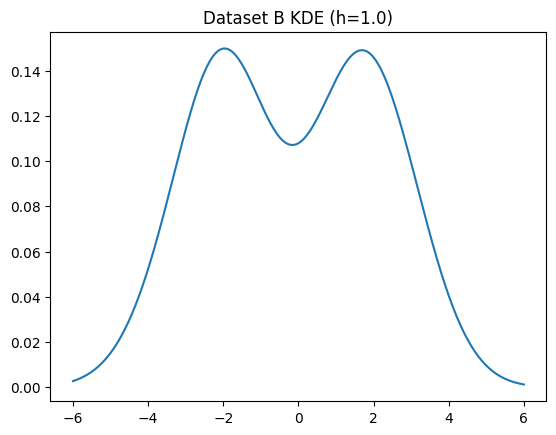

In [10]:
x_grid = np.linspace(-6, 6, 500)

for h in [0.2, 0.5, 1.0]:
    plt.figure()
    plt.plot(x_grid, kde(x_grid, X_A, h))
    plt.title(f"Dataset A KDE (h={h})")
    plt.show()

for h in [0.2, 0.5, 1.0]:
    plt.figure()
    plt.plot(x_grid, kde(x_grid, X_B, h))
    plt.title(f"Dataset B KDE (h={h})")
    plt.show()

## Mode Definition

A mode corresponds to a local maximum:

$$
f(x_i) > f(x_{i-1}) \quad \text{and} \quad f(x_i) > f(x_{i+1})
$$

- We count number of such peaks in the KDE.
- A distribution is unimodal if it has exactly one peak.

In [11]:
def count_modes(density):
    count = 0
    for i in range(1, len(density)-1):
        if density[i] > density[i-1] and density[i] > density[i+1]:
            count += 1
    return count

## Critical Bandwidth

Defined as:

$$
\hat{h} = \min \{ h : \hat{f}_h(x) \text{ is unimodal} \}
$$

---

## Interpretation

- Measures how much smoothing is required
- Larger value → stronger evidence of multiple modes

In [12]:
def critical_bandwidth(data, x_grid):
    for h in np.linspace(0.1, 2.0, 50):
        density = kde(x_grid, data, h)
        if count_modes(density) == 1:
            return h
    return None

h_A = critical_bandwidth(X_A, x_grid)
h_B = critical_bandwidth(X_B, x_grid)

print("Critical bandwidth A:", h_A)
print("Critical bandwidth B:", h_B)

Critical bandwidth A: 0.29387755102040813
Critical bandwidth B: 1.689795918367347


## Bootstrap

In [13]:
def bootstrap_asl(data, h_hat, B=500):
    n = len(data)
    count = 0

    for _ in range(B):
        sample = np.random.choice(data, size=n, replace=True)
        h_star = critical_bandwidth(sample, x_grid)

        if h_star is not None and h_star >= h_hat:
            count += 1

    return count / B

asl_A = bootstrap_asl(X_A, h_A)
asl_B = bootstrap_asl(X_B, h_B)

print("ASL A:", asl_A)
print("ASL B:", asl_B)

ASL A: 0.914
ASL B: 0.122


## Results and Interpretation

We use significance level:

$$
\alpha = 0.05
$$

Decision rule:

$$
\text{Reject } H_0 \text{ if } ASL < \alpha
$$

---

### Dataset A:
- Small critical bandwidth $\hat{h}$
- ASL is relatively high $$ (ASL > 0.05) $$
- Do not reject $H_0$
- Conclusion: Distribution is unimodal

---

### Dataset B:
- Larger critical bandwidth $\hat{h}$
- ASL is small $$ (ASL < 0.05) $$
- Reject $H_0$
- Conclusion: Distribution is not unimodal (bimodal)

---

## Final Insight

The test does not directly count modes.

Instead, it measures:

$$
\text{How much smoothing is required to enforce unimodality}
$$

- Small smoothing → inherently unimodal  
- Large smoothing → hidden multiple modes  

Thus, higher smoothing requirement provides statistical evidence against unimodality.